In [2]:
import sklearn
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier

In [3]:
#files (I'm really only using the first one)
tfrecord_train_00 = "/Users/altheawu/Downloads/UMBC/Next_Day_Wildfire/next_day_wildfire_spread_train_01.tfrecord"
tfrecord_test_00 = "/Users/altheawu/Downloads/UMBC/Next_Day_Wildfire/next_day_wildfire_spread_test_00.tfrecord"
tfrecord_eval_00 = "/Users/altheawu/Downloads/UMBC/Next_Day_Wildfire/next_day_wildfire_spread_eval_00.tfrecord"

In [4]:
feature_length = 4096  # all features have this length

feature_description = {
    'tmmx': tf.io.FixedLenFeature([feature_length], tf.float32),
    'FireMask': tf.io.FixedLenFeature([feature_length], tf.float32),
    'PrevFireMask': tf.io.FixedLenFeature([feature_length], tf.float32),
    'th': tf.io.FixedLenFeature([feature_length], tf.float32),
    'erc': tf.io.FixedLenFeature([feature_length], tf.float32),
    'vs': tf.io.FixedLenFeature([feature_length], tf.float32),
    'elevation': tf.io.FixedLenFeature([feature_length], tf.float32),
    'tmmn': tf.io.FixedLenFeature([feature_length], tf.float32),
    'NDVI': tf.io.FixedLenFeature([feature_length], tf.float32),
    'sph': tf.io.FixedLenFeature([feature_length], tf.float32),
    'pdsi': tf.io.FixedLenFeature([feature_length], tf.float32),
    'pr': tf.io.FixedLenFeature([feature_length], tf.float32),
    'population': tf.io.FixedLenFeature([feature_length], tf.float32),
}

def _parse_function(proto):
    return tf.io.parse_single_example(proto, feature_description)

dataset = tf.data.TFRecordDataset(tfrecord_train_00)
parsed_dataset = dataset.map(_parse_function)

# Define the list of feature names and the label name
features_to_extract = ['tmmx', 'PrevFireMask', 'th', 'erc', 'vs', 'elevation',
                       'tmmn', 'NDVI', 'sph', 'pdsi', 'pr', 'population']
label_to_extract = 'FireMask'

Wholde dataset

In [17]:
all_features_data = [[],[],[],[],[],[],[],[],[],[],[],[]]
all_labels_data = []

for parsed_record in parsed_dataset:
  for i in range(len(features_to_extract)):
    all_features_data[i].append(parsed_record[features_to_extract[i]].numpy())

    # Extract the label (FireMask) for the current recor
  all_labels_data.append(parsed_record[label_to_extract].numpy())

# Convert the lists of data into numpy arrays
all_features_data = np.array(all_features_data)

X_transposed = all_features_data.transpose(1, 2, 0)
X_final = X_transposed.reshape(-1, 12)

# Convert the lists of data into numpy arrays
X = np.array(X_final)
y = np.array(all_labels_data).flatten()

#Filtering out -1 pixels
mask = y != -1
X = X[mask]
y = y[mask]

# Sanity check
assert set(np.unique(y)).issubset({0, 1}), "Found unexpected labels!"


print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")

Shape of features (X): (4007752, 12)
Shape of labels (y): (4007752,)


In [5]:
#Logistic Regression
all_features_data = [[],[],[],[],[],[],[],[],[],[],[],[]]
all_labels_data = []

for parsed_record in parsed_dataset:
  if parsed_record['FireMask'].numpy().mean() >= 0:
    for i in range(len(features_to_extract)):
        all_features_data[i].append(parsed_record[features_to_extract[i]].numpy())
    all_labels_data.append(parsed_record[label_to_extract].numpy())

all_features_data = np.array(all_features_data)

# Shape: (n_records, 64, 64, 12)
X_transposed = all_features_data.transpose(1, 2, 0).reshape(-1, 64, 64, 12)
# Shape: (n_records, 64, 64)
y_grid = np.array(all_labels_data).reshape(-1, 64, 64)

n_records = X_transposed.shape[0]
X_neighbors = []
y_neighbors = []

for rec in range(n_records):
    # Exclude 1-pixel border: iterate rows 1..62, cols 1..62
    for r in range(1, 63):
        for c in range(1, 63):
            label = y_grid[rec, r, c]
            if label == -1:
                continue  # skip no-data pixels

            # Extract 3x3 neighborhood for all 12 features, then flatten
            # Shape: (3, 3, 12) -> (108,)
            neighborhood = X_transposed[rec, r-1:r+2, c-1:c+2, :]
            X_neighbors.append(neighborhood.flatten())
            y_neighbors.append(label)

X = np.array(X_neighbors)  # shape: (n_valid_pixels, 108)
y = np.array(y_neighbors)  # shape: (n_valid_pixels,)

assert set(np.unique(y)).issubset({0, 1}), "Found unexpected labels!"
print(f"Shape of features (X): {X.shape}")  # e.g. (n, 108)
print(f"Shape of labels (y): {y.shape}")
print(f"Label distribution: {np.bincount(y.astype(int))}")

I0000 00:00:1778518762.395780 36083859 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Shape of features (X): (3265643, 108)
Shape of labels (y): (3265643,)
Label distribution: [3220517   45126]


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(n_jobs =-1, max_depth=4)

In [18]:
estimators = [
    ('lr', lr_model),
    ('rf', rf_model)
]

# Initialize the StackingClassifier
# The final_estimator is the model that combines the predictions of the base estimators.
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)

stacking_classifier.fit(X_train, y_train)

/Users/altheawu/Downloads/UMBC/Models/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/altheawu/Downloads/UMBC/Models/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('rf', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inve

In [19]:
test_y = y_test
test_x = X_test
predictions = stacking_classifier.predict(test_x)


In [20]:
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

overall_precision = precision_score(test_y, predictions, average = 'macro')
overall_recall = recall_score(test_y, predictions, average = 'macro')
overall_f1 = f1_score(test_y, predictions, average = 'macro')


# Calculate accuracy
print("Accuracy:", accuracy_score(test_y, predictions))

print(f"Overall Precision: {overall_precision}")
print(f"Overall Recall: {overall_recall}")
print(f"Overall F1 Score: {overall_f1}")

print("Classification Report:\n", classification_report(test_y, predictions))




Accuracy: 0.9879184231571042
Overall Precision: 0.7629086226211155
Overall Recall: 0.5640731217608392
Overall F1 Score: 0.6013034864194668
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99    791693
         1.0       0.54      0.13      0.21      9858

    accuracy                           0.99    801551
   macro avg       0.76      0.56      0.60    801551
weighted avg       0.98      0.99      0.98    801551



In [12]:
#Single record prediction visualization
#For one to put on the slides, skipping 2 records is good

dataset = tf.data.TFRecordDataset(tfrecord_train_00)

num_records_to_skip = 2

second_parsed_dataset = dataset.map(_parse_function).skip(num_records_to_skip).take(1)

features_data = [[],[],[],[],[],[],[],[],[],[],[],[]]
labels_data = []

for parsed_record in second_parsed_dataset:
  #if parsed_record['FireMask'].numpy().mean() >= 0:
    for i in range(len(features_to_extract)):
        features_data[i].append(parsed_record[features_to_extract[i]].numpy())
    labels_data.append(parsed_record[label_to_extract].numpy())

features_data = np.array(features_data)

print(f"Shape of features_data: {features_data.shape}") 

# Shape: (n_records, 64, 64, 12)
X_transposed_single = features_data.transpose(1, 2, 0).reshape(-1, 64, 64, 12)
# Shape: (n_records, 64, 64)
y_grid_single = np.array(labels_data).reshape(-1, 64, 64)

n_records = X_transposed_single.shape[0]
X_neighbors_single = []
y_neighbors_single = []

for rec in range(n_records):
    # Exclude 1-pixel border: iterate rows 1..62, cols 1..62
    for r in range(1, 63):
        for c in range(1, 63):
            label = y_grid_single[rec, r, c]

            # Extract 3x3 neighborhood for all 12 features, then flatten
            # Shape: (3, 3, 12) -> (108,)
            neighborhood_single = X_transposed_single[rec, r-1:r+2, c-1:c+2, :]
            X_neighbors_single.append(neighborhood_single.flatten())
            y_neighbors_single.append(label)

X_single = np.array(X_neighbors_single)  # shape: (n_valid_pixels, 108)
y_single = np.array(y_neighbors_single)  # shape: (n_valid_pixels,)

#assert set(np.unique(y_single)).issubset({0, 1}), "Found unexpected labels!"
print(f"Shape of features (X): {X_single.shape}")  # e.g. (n, 108)
print(f"Shape of labels (y): {y_single.shape}")
#print(f"Label distribution: {np.bincount(y_single.astype(int))}")

Shape of features_data: (12, 1, 4096)
Shape of features (X): (3844, 108)
Shape of labels (y): (3844,)


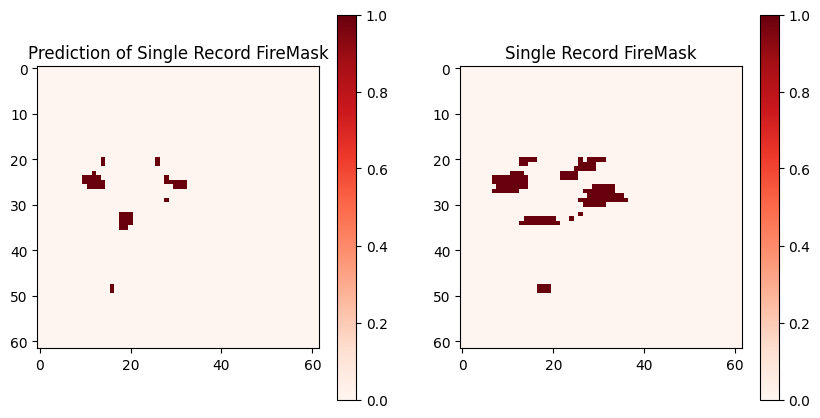

In [43]:
single_record_prediction = stacking_classifier.predict(X_single)

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.title(f"Prediction of Single Record FireMask")
plt.imshow(single_record_prediction.reshape(62,62), cmap="Reds")
plt.colorbar()

plt.subplot(1,2,2)
plt.title(f"Single Record FireMask")
plt.imshow(y_single.reshape(62,62), cmap="Reds")
plt.colorbar()

plt.show()